# Limb-darkened stars

A star's disk is not uniformly bright. Near the limb we look obliquely into the photosphere and see higher, cooler layers, so the specific intensity falls from the centre of the disk towards its edge. Interferometers resolve this directly: limb darkening barely changes the first lobe of the visibility, where it mimics a slightly smaller uniform disk, but it changes the depth of the nulls and the height of the second lobe. This notebook introduces virgil's limb-darkened disks, shows what they look like in the image and in the visibilities, explains the parametrization we recommend for fitting them, and fits simulated VLTI data.

The brightness is written as a function of $\mu = \sqrt{1 - (r/R)^2}$, the cosine of the angle between the line of sight and the surface normal. [Quirrenbach et al. (1996)](https://ui.adsabs.harvard.edu/abs/1996A%26A...312..160Q) showed (their eqs. 1–4) that a profile $I(\mu) = \sum_\nu a_\nu \mu^\nu$ has the visibility

$$
V(x) = \frac{1}{C} \sum_\nu a_\nu\, 2^{\nu/2}\, \Gamma\!\left(\frac{\nu}{2} + 1\right) \frac{J_{\nu/2+1}(x)}{x^{\nu/2+1}}, \qquad C = \sum_\nu \frac{a_\nu}{\nu + 2},
$$

with $x = \pi \theta B / \lambda$ for a limb-darkened diameter $\theta$ and baseline $B$. A uniform disk ($a_0 = 1$) recovers the familiar $2 J_1(x)/x$. [harmonix](https://github.com/shashankdholakia/harmonix) ([Dholakia & Pope 2025](https://arxiv.org/abs/2509.25433)) generalises this result to limb-darkened spherical-harmonic maps of spotted stars; for an unspotted star the two agree to machine precision. virgil evaluates the sum analytically and differentiably, with Bessel functions from [jaxbessel](https://github.com/benjaminpope/jaxbessel), and the powers $\nu$ need not be integers.

Three classes cover the common cases:

* `LimbDarkenedDisk(diam, u)`: the polynomial law $I(\mu)/I(1) = 1 - \sum_n u_n (1 - \mu)^n$ of any order, in the same convention (and with the same `u`) as jaxoplanet, *starry* and harmonix;
* `QuadraticLimbDarkenedDisk(diam, q1, q2)`: the quadratic law in the parametrization of [Kipping (2013)](https://doi.org/10.1093/mnras/stt1435);
* `SquareRootLimbDarkenedDisk(diam, q1, q2)`: the square-root law $1 - c(1-\mu) - d(1-\sqrt{\mu})$, also in Kipping's parametrization.

## Profiles and visibilities

We set up the imports and compare four stars of the same 6 mas limb-darkened diameter: a uniform disk, a linear law, and quadratic and square-root laws with coefficients typical of a cool giant in the near-infrared. On the left are the brightness profiles across the disk, normalised to the centre; on the right are the squared visibilities against $x$, on a logarithmic scale so that the nulls and the second lobe are visible. The darker the limb, the more the light is concentrated towards the centre, so the star looks smaller to an interferometer: the first null moves to longer baselines and the second lobe rises.

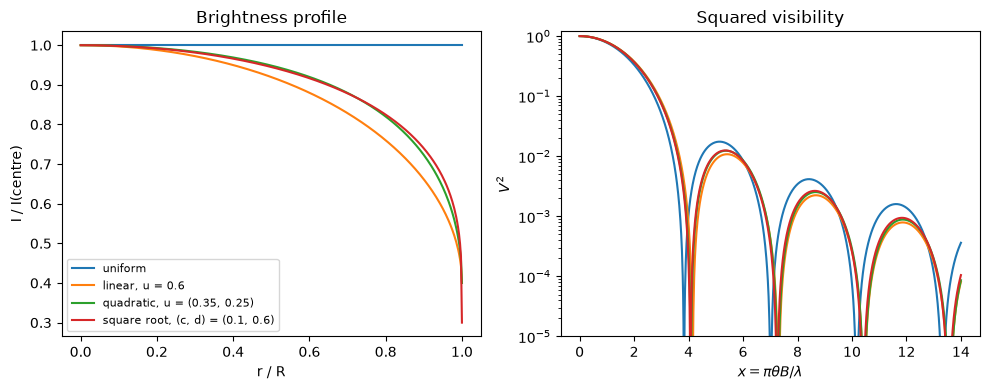

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import matplotlib.pyplot as plt
import numpy as onp
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value

from virgil.coverage import vlti_oidata
from virgil.fitting import fit
from virgil.likelihood import numpyro_model, whitened_residuals
from virgil.models import (
    LimbDarkenedDisk,
    QuadraticLimbDarkenedDisk,
    SquareRootLimbDarkenedDisk,
    UniformDisk,
)
from virgil.plotting import plot_model

diam = 6.0
stars = {
    "uniform": LimbDarkenedDisk(diam),
    "linear, u = 0.6": LimbDarkenedDisk(diam, u=[0.6]),
    "quadratic, u = (0.35, 0.25)": QuadraticLimbDarkenedDisk.from_u(
        diam, u1=0.35, u2=0.25
    ),
    "square root, (c, d) = (0.1, 0.6)": SquareRootLimbDarkenedDisk.from_cd(
        diam, c=0.1, d=0.6
    ),
}
profiles = {
    "uniform": lambda mu: onp.ones_like(mu),
    "linear, u = 0.6": lambda mu: 1 - 0.6 * (1 - mu),
    "quadratic, u = (0.35, 0.25)": lambda mu: 1
    - 0.35 * (1 - mu)
    - 0.25 * (1 - mu) ** 2,
    "square root, (c, d) = (0.1, 0.6)": lambda mu: 1
    - 0.1 * (1 - mu)
    - 0.6 * (1 - onp.sqrt(mu)),
}

# x = pi theta B / lambda, so baselines in wavelengths are x / (pi theta)
mas = onp.pi / 180 / 3600e3
x = onp.linspace(1e-3, 14.0, 1000)
spatial_frequency = x / (onp.pi * diam * mas)
r = onp.linspace(0.0, 1.0, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for name, star in stars.items():
    ax1.plot(r, profiles[name](onp.sqrt(1 - r**2)), label=name)
    vis = star.model(spatial_frequency, 0 * spatial_frequency, 1.0)
    ax2.semilogy(x, onp.abs(onp.asarray(vis)) ** 2)
ax1.set(xlabel="r / R", ylabel="I / I(centre)", title="Brightness profile")
ax1.legend(fontsize=8)
ax2.set(
    xlabel=r"$x = \pi\theta B/\lambda$",
    ylabel="$V^2$",
    ylim=(1e-5, 1.2),
    title="Squared visibility",
)
plt.tight_layout()
plt.show()

Like every virgil component, the disks render on the sky. `plot_model` draws the quadratic star next to the uniform disk; the limb-darkened star has the same outline but a brighter centre.

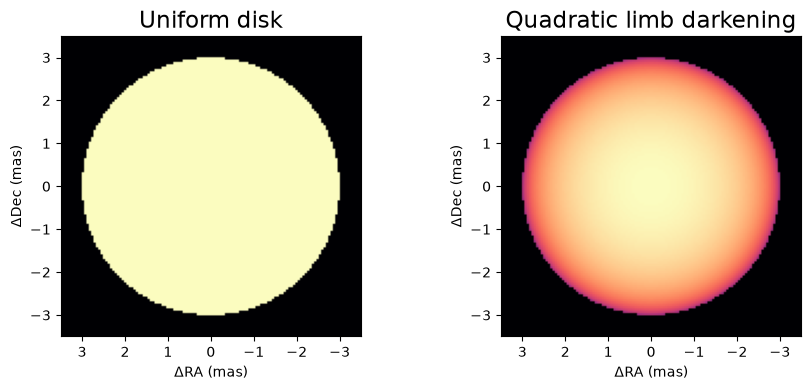

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_model(UniformDisk(diam), fov_mas=7.0, npix=128, ax=axes[0], title="Uniform disk")
plot_model(
    stars["quadratic, u = (0.35, 0.25)"],
    fov_mas=7.0,
    npix=128,
    ax=axes[1],
    title="Quadratic limb darkening",
)
plt.tight_layout()
plt.show()

## Kipping's parametrization

Not every pair of coefficients is a sensible star. For the quadratic law, the profile is positive everywhere and decreases monotonically from the centre to the limb only if $u_1 + u_2 < 1$, $u_1 > 0$ and $u_1 + 2u_2 > 0$, a triangle in the $(u_1, u_2)$ plane. Independent uniform priors on $u_1$ and $u_2$ either cover unphysical profiles or cut physical ones out. [Kipping (2013)](https://doi.org/10.1093/mnras/stt1435) mapped the triangle onto the unit square:

$$
u_1 = 2\sqrt{q_1}\, q_2, \qquad u_2 = \sqrt{q_1}\,(1 - 2 q_2), \qquad 0 \le q_1, q_2 \le 1,
$$

so that uniform priors on $q_1$ and $q_2$ sample every physical quadratic law, and only those, uniformly. The same construction works for the square-root law, with $c = \sqrt{q_1}(1 - 2q_2)$ and $d = 2\sqrt{q_1}\, q_2$. `QuadraticLimbDarkenedDisk` and `SquareRootLimbDarkenedDisk` take $q_1, q_2$ as their parameters, so `Uniform(0, 1)` priors on both are uninformative over the physical laws; `from_u` and `from_cd` convert tabulated coefficients, and the `u1`, `u2` (or `c`, `d`) properties convert back.

Below, uniform draws in $(q_1, q_2)$ fill exactly the physical triangle in $(u_1, u_2)$ (left), and every one of the corresponding profiles is positive and falls towards the limb (right, a random subset).

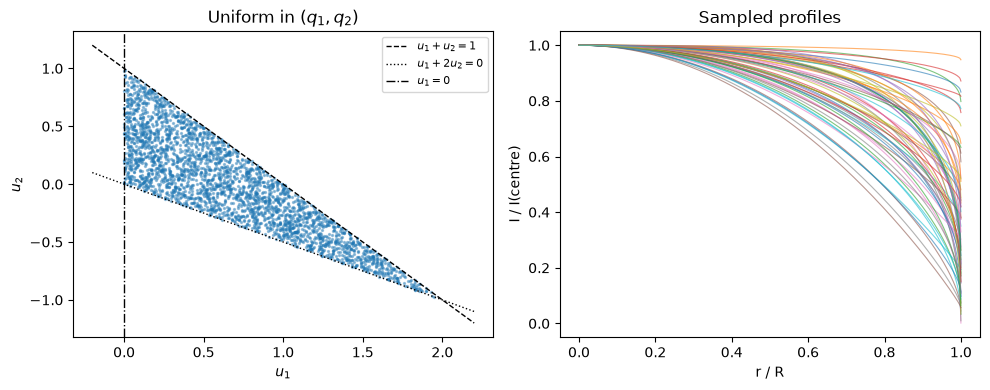

In [3]:
rng = onp.random.default_rng(0)
q1, q2 = rng.uniform(size=(2, 3000))
star = QuadraticLimbDarkenedDisk(diam, q1=q1, q2=q2)
u1, u2 = onp.asarray(star.u1), onp.asarray(star.u2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(u1, u2, s=2, alpha=0.4)
grid = onp.linspace(-0.2, 2.2, 2)
ax1.plot(grid, 1 - grid, "k--", lw=1, label="$u_1 + u_2 = 1$")
ax1.plot(grid, -grid / 2, "k:", lw=1, label="$u_1 + 2u_2 = 0$")
ax1.axvline(0, color="k", lw=1, ls="-.", label="$u_1 = 0$")
ax1.set(xlabel="$u_1$", ylabel="$u_2$", title="Uniform in $(q_1, q_2)$")
ax1.legend(fontsize=8)
mu = onp.sqrt(1 - r**2)
for a, b in zip(u1[:60], u2[:60]):
    ax2.plot(r, 1 - a * (1 - mu) - b * (1 - mu) ** 2, lw=0.8, alpha=0.6)
ax2.set(xlabel="r / R", ylabel="I / I(centre)", title="Sampled profiles")
plt.tight_layout()
plt.show()

## Fitting simulated VLTI data

To measure limb darkening the data have to reach beyond the first null. `vlti_oidata` makes VLTI-like coverage with the four unit telescopes, three snapshots and six channels between 1.6 and 2.4 microns; for a 6 mas star the longest baselines reach the second lobe. We fill it with the squared visibilities and closure phases of a quadratic-law star plus noise, and fit it twice: once with a uniform disk, and once with `fit`, `QuadraticLimbDarkenedDisk` with a `LogUniform(2, 10)` prior on the diameter (a scale) and `Uniform(0, 1)` priors on $q_1$ and $q_2$. The uniform disk has one parameter, and its closure phases flip between 0 and 180 degrees at every null, which makes its chi-squared jump as the diameter changes, so we fit it with a fine scan rather than a gradient-based optimizer. The uniform disk can match the first lobe only by shrinking, and then fails in the second, with a reduced chi-squared in the hundreds; the limb-darkened model fits the data.

In [4]:
truth = QuadraticLimbDarkenedDisk.from_u(diam, u1=0.35, u2=0.25)
template = vlti_oidata(
    wavelengths_m=onp.linspace(1.6e-6, 2.4e-6, 6),
    hour_angles_h=(-2.5, 0.0, 2.5),
    sigma_v2=0.002,
    sigma_cp_deg=0.5,
)
data = template.with_model(truth, key=jax.random.PRNGKey(3))

# A uniform disk's closure phases flip between 0 and 180 degrees at each null,
# so its chi-squared jumps as the diameter changes: fit its one parameter
# with a fine scan.
diams = onp.linspace(4.0, 8.0, 2001)
chi2 = [onp.sum(whitened_residuals(UniformDisk(d), data) ** 2) for d in diams]
ud_model = UniformDisk(diams[onp.argmin(chi2)])

priors = {
    "diam": dist.LogUniform(2.0, 10.0),
    "q1": dist.Uniform(0.0, 1.0),
    "q2": dist.Uniform(0.0, 1.0),
}
ld = fit(QuadraticLimbDarkenedDisk(5.0, q1=0.5, q2=0.5), priors, data)
for name, model in [("uniform disk", ud_model), ("limb-darkened", ld.model)]:
    residuals = onp.asarray(whitened_residuals(model, data))
    print(
        f"{name:>13}: diam = {float(model.diam):.3f} mas, "
        f"chi2 per point {onp.mean(residuals**2):.2f} ({residuals.size} points)"
    )

 uniform disk: diam = 5.686 mas, chi2 per point 451.32 (234 points)
limb-darkened: diam = 6.022 mas, chi2 per point 0.79 (234 points)


A point estimate hides how well the limb darkening is actually measured. Because the priors are bounded and $q_1, q_2$ are nonlinear functions of $u_1, u_2$, a Gaussian (Laplace) approximation is a poor description here, so we sample the posterior with NUTS: `numpyro_model` turns the template and the priors into a numpyro model, with no hand-written model function. On the left is the posterior in Kipping's $(q_1, q_2)$, where the prior is uniform over the whole square; on the right are the same samples mapped to $(u_1, u_2)$, inside the physical triangle. The data constrain a combination of the two coefficients much better than either alone, as is usual for limb darkening: $u_1$ and $u_2$ are strongly anticorrelated, and the diameter is correlated with both, since a darker limb also makes the star look smaller.

         truth         posterior
  diam   6.000      6.037 ± 0.054
    q1   0.360      0.536 ± 0.215
    q2   0.292      0.150 ± 0.117
    u1   0.350      0.219 ± 0.110
    u2   0.250      0.519 ± 0.248


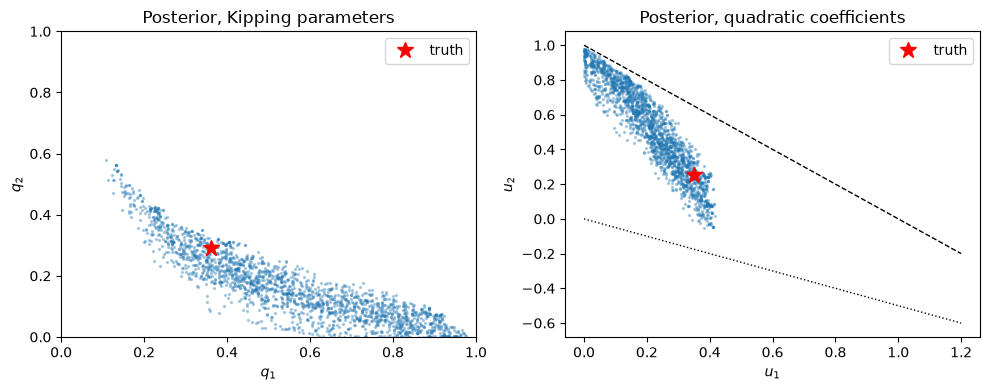

In [5]:
kernel = NUTS(
    numpyro_model(ld.model, priors, data),
    init_strategy=init_to_value(values={p: ld.values[p] for p in priors}),
    dense_mass=True,
)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc.run(jax.random.PRNGKey(4))
posterior = mcmc.get_samples()
samples = QuadraticLimbDarkenedDisk(
    posterior["diam"], q1=posterior["q1"], q2=posterior["q2"]
)
derived = {
    "diam": posterior["diam"],
    "q1": posterior["q1"],
    "q2": posterior["q2"],
    "u1": samples.u1,
    "u2": samples.u2,
}
print(f"{'':>6}{'truth':>8}{'posterior':>18}")
for name, values in derived.items():
    values = onp.asarray(values)
    print(
        f"{name:>6}{float(getattr(truth, name)):8.3f}"
        f"{onp.median(values):11.3f} ± {onp.std(values):.3f}"
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(posterior["q1"], posterior["q2"], s=2, alpha=0.3)
ax1.plot(truth.q1, truth.q2, "r*", ms=12, label="truth")
ax1.set(xlim=(0, 1), ylim=(0, 1), xlabel="$q_1$", ylabel="$q_2$",
        title="Posterior, Kipping parameters")
ax1.legend()
ax2.scatter(samples.u1, samples.u2, s=2, alpha=0.3)
ax2.plot(truth.u1, truth.u2, "r*", ms=12, label="truth")
grid = onp.linspace(0.0, 1.2, 2)
ax2.plot(grid, 1 - grid, "k--", lw=1)
ax2.plot(grid, -grid / 2, "k:", lw=1)
ax2.set(xlabel="$u_1$", ylabel="$u_2$", title="Posterior, quadratic coefficients")
ax2.legend()
plt.tight_layout()
plt.show()

The squared visibilities against spatial frequency show where the difference lies. Both fits agree in the first lobe; beyond the first null the uniform disk's second lobe is too low, while the limb-darkened model follows the data.

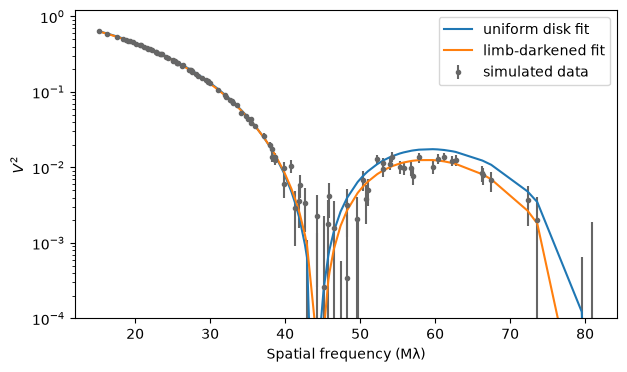

In [6]:
n_vis = data.vis.size
frequency = onp.hypot(onp.asarray(data.u), onp.asarray(data.v)) / onp.asarray(data.wavel)
order = onp.argsort(frequency)
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(frequency / 1e6, onp.asarray(data.vis), onp.asarray(data.d_vis),
            fmt=".", color="0.4", label="simulated data")
for model, label in [(ud_model, "uniform disk fit"), (ld.model, "limb-darkened fit")]:
    model_v2 = onp.asarray(data.model(model))[:n_vis]
    ax.plot(frequency[order] / 1e6, model_v2[order], label=label)
ax.set(yscale="log", ylim=(1e-4, 1.2), xlabel="Spatial frequency (Mλ)",
       ylabel="$V^2$")
ax.legend()
plt.show()

## Summary

virgil's limb-darkened disks give analytic, differentiable visibilities for any law that is a sum of powers of $\mu$, through Quirrenbach et al.'s (1996) result, which harmonix generalises to spotted stars. Use `LimbDarkenedDisk` with a jaxoplanet-style `u` for polynomial laws of any order, and `QuadraticLimbDarkenedDisk` or `SquareRootLimbDarkenedDisk` to fit two-parameter laws with Kipping's (2013) $q_1, q_2$, whose Uniform(0, 1) priors cover exactly the physical profiles. Limb darkening is only measurable with baselines that reach the first null or beyond; at shorter baselines it is degenerate with the diameter. Laws that are not sums of powers of $\mu$, such as the logarithmic and exponential laws, are not included.

## As a pipeline

Everything in the fit above can be run in one call with [`StarPipeline`](pipeline.md), which fixes the order of the steps and writes a run folder that reloads without recomputing. The simulated `data` are its input and the `load` stage; the uniform-disk scan and the `fit` of `QuadraticLimbDarkenedDisk` are its `fit` stage, which also compares the two fits; the NUTS chains are its `posterior` stage; and the $V^2$ plot is the main cell of its quicklook notebook. The cell below sets only the choices made in this notebook: the same $(2, 10)$ mas diameter prior and the same warmup, with the default four chains of 1000 draws. Its priors are the pipeline's group-invariant defaults (log-uniform diameter, uniform $q_1$ and $q_2$), so the posterior agrees with the hand-written one to within the sampling noise, not exactly. The pipeline reports $\chi^2/N$ on the quoted errors for both models, so the uniform disk's failure is visible there too. The data's closure-phase errors are 0.5 degrees, so a closure phase that flips at a visibility null costs about $10^5$ in $\chi^2$: the posterior sits in a cell with hard walls, in the diameter and in $q_1, q_2$ (a limb-darkened null moves with $q$). NUTS rejects the trajectories that cross a wall and flags them as divergent, so the `divergences` check reports a warning that names the walls rather than a failure; the draws agree with a brute-force grid posterior, but with a reduced effective sample size.

In [ ]:
from tempfile import mkdtemp

from virgil.pipeline import StarPipeline

res = StarPipeline(
    data,
    output=f"{mkdtemp()}/star_run",
    diam_range_mas=[2.0, 10.0],
    num_warmup=1000,
    num_samples=1000,
).run()

print(res.describe())

In [ ]:
import matplotlib.pyplot as plt

from virgil.pipeline.star import plot_v2_models

plot_v2_models(
    data,
    {"uniform disk": res.model("uniform"), "limb-darkened": res.model("limb_darkened")},
)
plt.show()

In [ ]:
fit = res.summary["fit"]["models"]
hand_ud = float(ud_model.diam)
hand_ld = float(ld.model.diam)
hand_post = float(onp.median(posterior["diam"]))
pipe_post = res.summary["posterior"]["models"]["limb_darkened"]["params"]
print(
    f"uniform disk:  hand diam={hand_ud:.3f}   pipeline diam={fit['uniform']['params']['diam']:.3f}\n"
    f"limb-darkened: hand diam={hand_ld:.3f}   pipeline diam={fit['limb_darkened']['params']['diam']:.3f}\n"
    f"posterior:     hand diam={hand_post:.3f}   pipeline diam={pipe_post['diam']['median']:.3f}"
)

# The pipeline reproduces the hand-computed numbers.
assert abs(fit["uniform"]["params"]["diam"] - hand_ud) < 0.02
assert abs(fit["limb_darkened"]["params"]["diam"] - hand_ld) < 0.05
assert abs(pipe_post["diam"]["median"] - hand_post) < 0.1
assert res.summary["fit"]["best"] == "limb_darkened"
assert fit["uniform"]["chi2_reduced"] > 100 > 2 > fit["limb_darkened"]["chi2_reduced"]